# A07 — A Tiny Statevector Simulator

**Track A — under the hood.** Pure NumPy. Qiskit is not imported anywhere in this
notebook.

---

## The one-sentence version

A quantum simulator is a list of $2^n$ complex numbers and a loop that keeps
updating it. The only interesting question is **how you do the update** — and the
obvious way is quadratically worse than the right way.

## The obvious way, and why it is a trap

A05 and A06 both did it the obvious way. To apply a gate $U$ to qubit $k$ of an
$n$-qubit register, build the big matrix

$$U^{(k)} = I \otimes \cdots \otimes U \otimes \cdots \otimes I$$

and multiply: `psi = U_big @ psi`. It is one line, it is correct, and it is how
almost every "build a quantum simulator in 50 lines" post on the internet does it.

Here is the problem. That matrix is $2^n \times 2^n$, so it holds $4^n$ numbers —
while the state it acts on holds only $2^n$. **The scratch space grows as the
square of the thing you are computing.** At 14 qubits the matrix is already 4 GB;
the statevector is 262 kB. You run out of memory for the *workspace* long before
you run out of memory for the *answer*.

And nearly all of that matrix is zeros. A single-qubit gate has exactly two
non-zero entries per row no matter how big $n$ gets, so at $n = 20$ the matrix is
99.9998% zero — a terabyte of carefully stored nothing.

## The right way, in one idea

Stop thinking of the state as a flat list of $2^n$ numbers. Think of it as an
$n$-dimensional array of shape $(2, 2, \ldots, 2)$ — one axis per qubit.

$$\psi[\,b_{n-1},\ \ldots,\ b_1,\ b_0\,] \qquad\text{instead of}\qquad \psi[i].$$

It is the same buffer, the same bytes; `reshape` does not move a single number.
But once the state has one axis per qubit, "apply $U$ to qubit $k$" becomes
literally what it says: **contract the $2\times 2$ matrix $U$ with axis $k$**, and
leave every other axis alone. NumPy does that with `tensordot`.

The cost of that contraction is $2 \cdot 2^n$ multiply-adds — **linear in the size
of the state**. No big matrix is ever formed, and none is ever needed.

## What this notebook does

1. Builds both simulators, side by side, and proves they agree to machine
   precision on random gates and random qubits.
2. Draws what "apply a gate" really is: $2^{n-1}$ independent $2\times2$ problems,
   picked out by a stride of $2^k$.
3. Benchmarks the two paths for real, with wall-clock numbers, and finds the
   crossover.
4. Plots the two walls — the $2^n$ state wall and the $4^n$ operator wall — and
   shows that forming the matrix costs you roughly **half your qubits**.
5. Says honestly what this toy cannot do.

In [1]:
from qviz import backends, grid, style

import time
from functools import reduce

import matplotlib.pyplot as plt
import numpy as np

style.use()

SEED = backends.seed_for("A07")
rng = np.random.default_rng(SEED)
print("seed:", SEED)

seed: 20260811


## 1. The naive simulator, restated

This is A05's `op_on`, unchanged, plus its two-qubit sibling. Little-endian
throughout: **qubit 0 is the rightmost label character**, so qubit $k$'s bit in
basis index $i$ is `(i >> k) & 1`, and qubit 0 is the *last* factor of the
Kronecker chain.

For the two-qubit version we have to pin down one extra convention: a $4\times4$
gate has its own two "wires", and we need to say which is which. The rule used
everywhere below is the same little-endian rule applied to the pair:

> In a $4\times4$ gate matrix acting on qubits `(qa, qb)`, the row/column index is
> $2 b_{qb} + b_{qa}$ — so **`qa` is the pair's low bit**, the one written on the
> right.

With that, the textbook CNOT array `[[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]]`
means "control `qb`, target `qa`", which is what it looks like on the page.

`op_on_pair` builds the big matrix by explicit bit surgery rather than by
`kron`, because the two qubits need not be adjacent — and because a second,
independent construction is the only way to be sure the first one is right.

In [2]:
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

CNOT4 = np.array([[1, 0, 0, 0],
                  [0, 1, 0, 0],
                  [0, 0, 0, 1],
                  [0, 0, 1, 0]], dtype=complex)      # control = pair high bit
CZ4 = np.diag([1, 1, 1, -1]).astype(complex)


def rz(theta):
    return np.diag([np.exp(-1j * theta / 2), np.exp(1j * theta / 2)]).astype(complex)


def label(i, n):
    """Printed bitstring: qubit n-1 leftmost, qubit 0 rightmost."""
    return format(i, f"0{n}b")


def op_on(U, k, n):
    """NAIVE: the full 2**n x 2**n matrix for U acting on qubit k.

    Little-endian, so qubit 0 is the RIGHTMOST factor: build the list in qubit
    order and reverse it before folding.
    """
    ops = [I2] * n
    ops[k] = np.asarray(U, dtype=complex)
    return reduce(np.kron, ops[::-1])


def op_on_pair(G, qa, qb, n):
    """NAIVE: the full 2**n x 2**n matrix for a 4x4 gate G on qubits (qa, qb).

    G's index convention is 2*b_qb + b_qa, i.e. qa is the pair's low bit.
    Built by scattering G's entries directly, so qa and qb need not be adjacent.
    """
    if qa == qb:
        raise ValueError("a two-qubit gate needs two different qubits")
    G = np.asarray(G, dtype=complex)
    D = 2 ** n
    M = np.zeros((D, D), dtype=complex)
    for j in range(D):
        col = 2 * ((j >> qb) & 1) + ((j >> qa) & 1)
        rest = j & ~((1 << qa) | (1 << qb))
        for ib in (0, 1):
            for ia in (0, 1):
                M[rest | (ia << qa) | (ib << qb), j] = G[2 * ib + ia, col]
    return M


def random_state(rng, n):
    """A Haar-random pure state on n qubits."""
    v = rng.normal(size=2 ** n) + 1j * rng.normal(size=2 ** n)
    return v / np.linalg.norm(v)


# Sanity: X on qubit 0 of |000> must land on index 1, printed |001>.
e0 = np.zeros(8, dtype=complex)
e0[0] = 1.0
print("X on qubit 0 of |000> -> |" +
      label(int(np.argmax(np.abs(op_on(X, 0, 3) @ e0))), 3) + ">")
print("X on qubit 2 of |000> -> |" +
      label(int(np.argmax(np.abs(op_on(X, 2, 3) @ e0))), 3) + ">")

# A 5-qubit single-qubit gate matrix: how much of it is actually there?
M = op_on(H, 2, 5)
nz = int(np.count_nonzero(np.abs(M) > 1e-12))
print(f"\nop_on(H, 2, 5) is {M.shape[0]}x{M.shape[1]} = {M.size} entries, "
      f"{nz} of them non-zero ({100 * nz / M.size:.1f}%).")

X on qubit 0 of |000> -> |001>
X on qubit 2 of |000> -> |100>

op_on(H, 2, 5) is 32x32 = 1024 entries, 64 of them non-zero (6.2%).


## 2. The reshape, and the one index rule that matters

`psi.reshape((2,) * n)` reinterprets the flat buffer as an $n$-dimensional array.
NumPy's default C ordering means the **first** axis varies slowest — it is the
*most significant* bit of the flat index. Our most significant bit is qubit
$n-1$. So:

$$\boxed{\ \text{axis } j \ \longleftrightarrow\ \text{qubit } n-1-j\ }$$

Get this backwards and every gate lands on the mirror-image qubit, silently. It
is the same off-by-a-reversal that A05 warned about for `kron`, wearing a
different hat.

Now the update itself. Writing the state with qubit $k$'s index pulled out,

$$\psi'[\ldots, b_k', \ldots] = \sum_{b_k} U_{b_k' b_k}\ \psi[\ldots, b_k, \ldots],$$

which is exactly `np.tensordot(U, T, axes=([1], [axis_k]))` — sum $U$'s column
index against that one axis of the tensor. `tensordot` pushes the surviving axis
of $U$ to the **front** of the result, so we `moveaxis` it back to where qubit $k$
lives and reshape flat again.

Three lines. No $2^n \times 2^n$ anything.

The two-qubit case is the same idea with two axes at once: reshape the $4\times4$
gate to $(2,2,2,2)$ so its indices become
$G[b_{qb}', b_{qa}', b_{qb}, b_{qa}]$, contract its two input axes against the two
qubit axes, and move the two output axes home.

In [3]:
def axis_of(k, n):
    """Which tensor axis holds qubit k. Little-endian: axis j <-> qubit n-1-j."""
    return n - 1 - k


def apply_1q(psi, U, k, n):
    """FAST: apply a 2x2 gate to qubit k without ever forming a big matrix."""
    ax = axis_of(k, n)
    T = psi.reshape((2,) * n)
    T = np.tensordot(U, T, axes=([1], [ax]))     # contracted axis -> front
    T = np.moveaxis(T, 0, ax)                    # ...put it back
    return T.reshape(-1)


def apply_2q(psi, G, qa, qb, n):
    """FAST: apply a 4x4 gate to qubits (qa, qb); qa is the pair's low bit."""
    axa, axb = axis_of(qa, n), axis_of(qb, n)
    T = psi.reshape((2,) * n)
    g = np.asarray(G, dtype=complex).reshape(2, 2, 2, 2)   # [b', a', b, a]
    T = np.tensordot(g, T, axes=([2, 3], [axb, axa]))      # two axes -> front
    T = np.moveaxis(T, [0, 1], [axb, axa])
    return T.reshape(-1)


# --- the same sanity check, through the fast path
psi = np.zeros(8, dtype=complex)
psi[0] = 1.0
print("X on qubit 0 of |000> -> |" +
      label(int(np.argmax(np.abs(apply_1q(psi, X, 0, 3)))), 3) + ">")
print("X on qubit 2 of |000> -> |" +
      label(int(np.argmax(np.abs(apply_1q(psi, X, 2, 3)))), 3) + ">")

# CNOT with control qubit 1, target qubit 0, acting on |010> (index 2).
psi = np.zeros(8, dtype=complex)
psi[2] = 1.0
out = apply_2q(psi, CNOT4, qa=0, qb=1, n=3)
print("CNOT(control q1, target q0) on |010> -> |" +
      label(int(np.argmax(np.abs(out))), 3) + ">   (expect |011>)")

X on qubit 0 of |000> -> |001>
X on qubit 2 of |000> -> |100>
CNOT(control q1, target q0) on |010> -> |011>   (expect |011>)


### Do the two paths actually agree?

Not "do they agree on CNOT" — that is the case both are most likely to get right.
Agree on **Haar-random unitaries, every qubit, every ordered pair of qubits, for
$n = 1 \ldots 6$**. A transposition bug or an endianness bug survives a symmetric
test gate and dies instantly against a random one.

In [4]:
def haar_unitary(dim, rng):
    """Haar-random unitary: QR of a complex Gaussian, with the phases fixed."""
    z = (rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))) / np.sqrt(2)
    q, r = np.linalg.qr(z)
    return q @ np.diag(np.diag(r) / np.abs(np.diag(r)))


worst_1q = 0.0
worst_2q = 0.0
n_cases = 0
for n in range(1, 7):
    state = random_state(rng, n)
    for k in range(n):
        U = haar_unitary(2, rng)
        d = np.max(np.abs(apply_1q(state, U, k, n) - op_on(U, k, n) @ state))
        worst_1q = max(worst_1q, float(d))
        n_cases += 1
    for qa in range(n):
        for qb in range(n):
            if qa == qb:
                continue
            G = haar_unitary(4, rng)
            d = np.max(np.abs(apply_2q(state, G, qa, qb, n)
                              - op_on_pair(G, qa, qb, n) @ state))
            worst_2q = max(worst_2q, float(d))
            n_cases += 1

print(f"{n_cases} random-gate cases, n = 1..6, every qubit and every ordered pair")
print(f"  worst single-qubit disagreement: {worst_1q:.3e}")
print(f"  worst two-qubit disagreement   : {worst_2q:.3e}")
print("  (machine epsilon for float64 is 2.2e-16)")

91 random-gate cases, n = 1..6, every qubit and every ordered pair
  worst single-qubit disagreement: 1.144e-16
  worst two-qubit disagreement   : 1.144e-16
  (machine epsilon for float64 is 2.2e-16)


## Figure 1 — what "apply a gate" actually is

Here is the picture that makes the whole method obvious.

Applying a $2\times2$ gate to qubit $k$ never mixes an amplitude with more than
one other amplitude. Index $i$ is combined with index $i \oplus 2^k$ — the same
basis state with qubit $k$ flipped — and with nothing else. So one gate is
$2^{n-1}$ completely **independent** $2\times2$ problems, and the only thing that
changes with $k$ is *which* pairs, at a stride of $2^k$.

Below, $n = 4$: sixteen amplitudes, four choices of $k$. Dots are coloured by
qubit $k$'s bit — grey for 0, orange for 1 — and every arc joins a grey to an
orange. Notice the dot colouring alone tells you the stride: alternating
singletons, then pairs, then blocks of four, then blocks of eight.

That block structure is precisely what `reshape` exposes for free, and it is why
`tensordot` can do this without looking at $4^n$ entries. A $2^n \times 2^n$
matrix would spend $4^n - 2^{n+1}$ of its entries recording that all the *other*
pairings are forbidden.

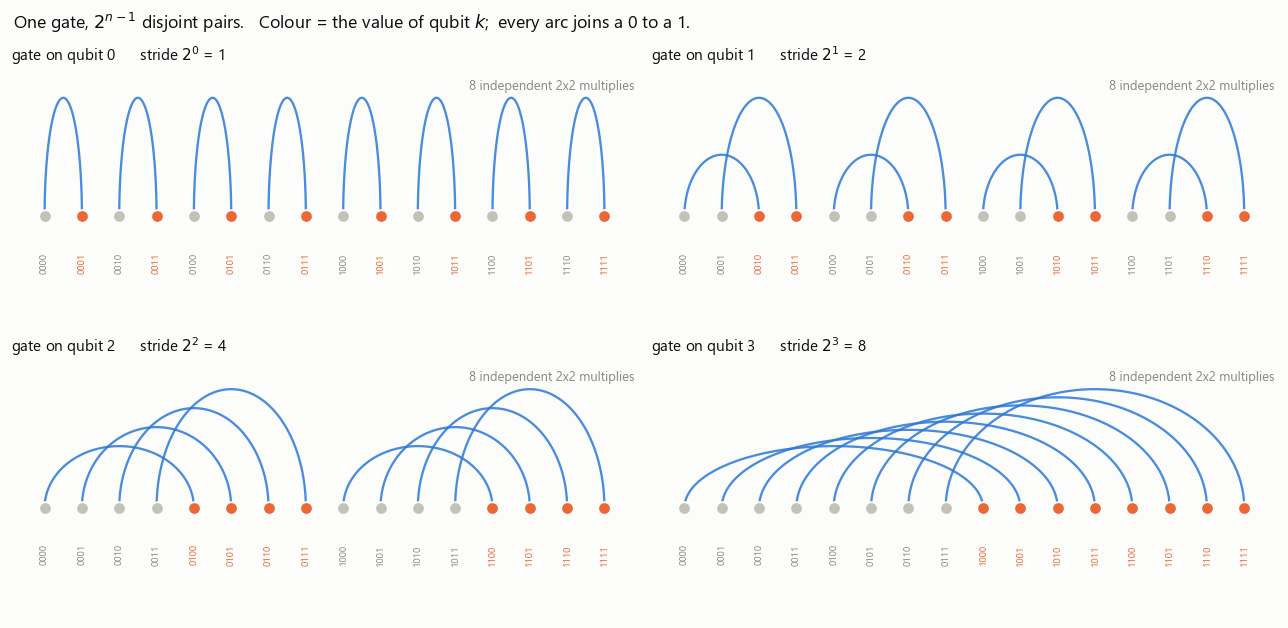

qubit 0: stride  1   first pairs (0,1), (2,3), (4,5), ... (8 total)
qubit 1: stride  2   first pairs (0,2), (1,3), (4,6), ... (8 total)
qubit 2: stride  4   first pairs (0,4), (1,5), (2,6), ... (8 total)
qubit 3: stride  8   first pairs (0,8), (1,9), (2,10), ... (8 total)


In [5]:
N_DEMO = 4
D_DEMO = 2 ** N_DEMO

fig, axes = plt.subplots(2, 2, figsize=(11.6, 5.6))
for k, ax in enumerate(axes.ravel()):
    stride = 2 ** k
    lows = [i for i in range(D_DEMO) if not (i >> k) & 1]
    for rank, i in enumerate(lows):
        j = i + stride
        if stride == 1:
            hgt = 1.0
        else:
            hgt = 0.52 + 0.48 * ((i % stride) / (stride - 1))
        th = np.linspace(0, np.pi, 60)
        ax.plot((i + j) / 2 + (stride / 2) * np.cos(th), hgt * np.sin(th),
                color=style.BLUE, lw=1.5, alpha=0.85, zorder=2,
                solid_capstyle="round")

    bits = np.array([(i >> k) & 1 for i in range(D_DEMO)])
    ax.scatter(np.arange(D_DEMO)[bits == 0], np.zeros(int((bits == 0).sum())),
               s=68, color=style.AXIS, edgecolor=style.SURFACE, linewidths=1.2,
               zorder=4)
    ax.scatter(np.arange(D_DEMO)[bits == 1], np.zeros(int((bits == 1).sum())),
               s=68, color=style.ORANGE, edgecolor=style.SURFACE, linewidths=1.2,
               zorder=4)

    for i in range(D_DEMO):
        ax.text(i, -0.30, label(i, N_DEMO), rotation=90, ha="center", va="top",
                fontsize=6.5,
                color=style.ORANGE if bits[i] else style.MUTED)

    ax.set_xlim(-0.9, D_DEMO - 0.1)
    ax.set_ylim(-0.92, 1.24)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(f"gate on qubit {k}      stride $2^{k}$ = {stride}",
                 loc="left", fontsize=10, pad=6)
    ax.text(D_DEMO - 0.2, 1.16, "8 independent 2x2 multiplies", ha="right",
            va="top", fontsize=8.5, color=style.MUTED)

fig.suptitle("One gate, $2^{n-1}$ disjoint pairs.   "
             "Colour = the value of qubit $k$;  every arc joins a 0 to a 1.",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

for k in range(N_DEMO):
    pairs = [(i, i ^ (1 << k)) for i in range(D_DEMO) if not (i >> k) & 1]
    print(f"qubit {k}: stride {2**k:>2}   first pairs " +
          ", ".join(f"({a},{b})" for a, b in pairs[:3]) + f", ... ({len(pairs)} total)")

## Figure 2 — the big matrix is almost entirely zeros

Figure 1 said a single-qubit gate touches $2^{n-1}$ disjoint pairs. Turn that into
a count of matrix entries: each row has exactly **two** non-zeros, forever,
independent of $n$. So the density of a single-qubit gate matrix is

$$\frac{2 \cdot 2^n}{4^n} = \frac{2}{2^n},$$

which halves with every qubit you add. The left two panels show it at $n = 5$;
the right panel extrapolates.

A CNOT is worse: it is a permutation matrix, so it has exactly *one* non-zero per
row — density $1/2^n$. The most useful gate in quantum computing, stored as a
dense array, is 99.99999% padding at 25 qubits.

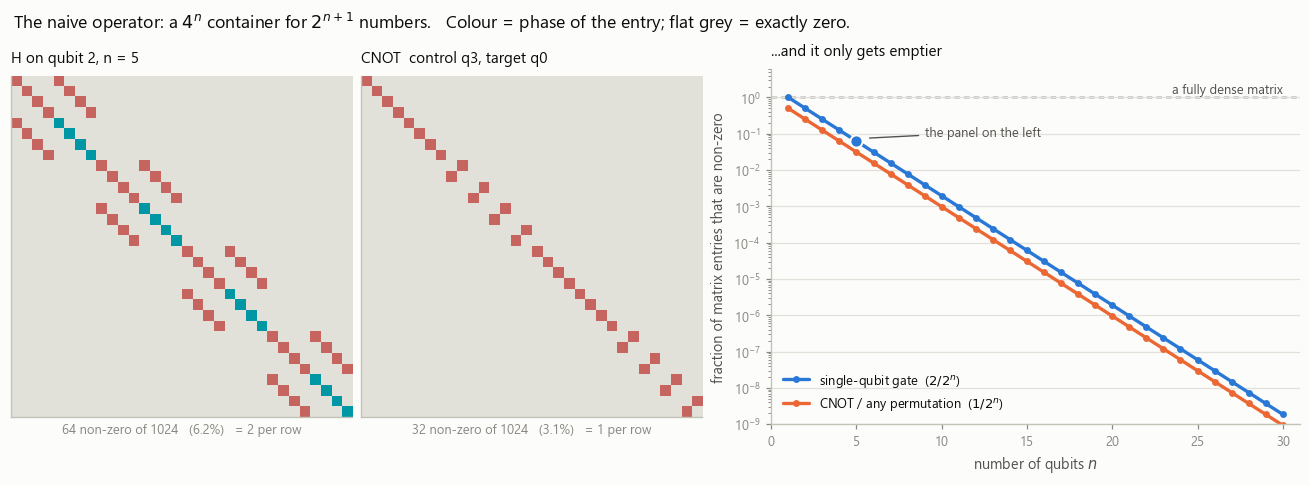

   n     matrix entries      non-zeros       wasted bytes
   5              1,024             64             15,360
  10          1,048,576          2,048         16,744,448
  15      1,073,741,824         65,536     17,178,820,608
  20  1,099,511,627,776      2,097,152 17,592,152,489,984
  25 1,125,899,906,842,624     67,108,864 18,014,397,435,740,160


In [6]:
N_SPARSE = 5
D_SPARSE = 2 ** N_SPARSE
M_h = op_on(H, 2, N_SPARSE)
M_cx = op_on_pair(CNOT4, qa=0, qb=3, n=N_SPARSE)

fig = plt.figure(figsize=(11.8, 4.3))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.55])

for col, (name, Mm, per_row) in enumerate([
        ("H on qubit 2, n = 5", M_h, 2),
        ("CNOT  control q3, target q0", M_cx, 1)]):
    ax = fig.add_subplot(gs[0, col])
    # part="phase" masks the exact zeros to flat grey, which is the whole point
    # here: an "abs" map would paint them the pale end of a ramp and they would
    # read as small values rather than as absence.
    grid.matrix(ax, Mm, part="phase", cbar=False, annot=False, title=name)
    nzc = int(np.count_nonzero(np.abs(Mm) > 1e-12))
    ax.set_xlabel(f"{nzc} non-zero of {Mm.size}   "
                  f"({100 * nzc / Mm.size:.1f}%)   "
                  f"= {per_row} per row",
                  fontsize=8.5, color=style.MUTED)

axd = fig.add_subplot(gs[0, 2])
ns = np.arange(1, 31)
axd.semilogy(ns, 2.0 / 2.0 ** ns, color=style.BLUE, lw=2.2, marker="o", ms=3.5,
             label="single-qubit gate  ($2/2^n$)")
axd.semilogy(ns, 1.0 / 2.0 ** ns, color=style.ORANGE, lw=2.2, marker="o", ms=3.5,
             label="CNOT / any permutation  ($1/2^n$)")
axd.axhline(1.0, color=style.INK, lw=0.9, ls=(0, (4, 3)), zorder=1)
axd.text(30, 1.35, "a fully dense matrix", ha="right", fontsize=8.5,
         color=style.INK_2)
axd.plot([N_SPARSE], [2.0 / 2.0 ** N_SPARSE], marker="o", ms=8,
         color=style.BLUE, markeredgecolor=style.SURFACE, markeredgewidth=1.3,
         zorder=5)
grid.annotate(axd, "the panel on the left", xy=(N_SPARSE + 0.5, 2.4 / 2 ** N_SPARSE),
              xytext=(9.0, 1.1e-1), color=style.INK_2)
axd.set_xlim(0, 31)
axd.set_ylim(1e-9, 6)
axd.set_xlabel("number of qubits $n$")
axd.set_ylabel("fraction of matrix entries that are non-zero")
axd.set_title("...and it only gets emptier", loc="left", fontsize=10)
axd.legend(loc="lower left")

fig.suptitle("The naive operator: a $4^n$ container for $2^{n+1}$ numbers.   "
             "Colour = phase of the entry; flat grey = exactly zero.",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"{'n':>4} {'matrix entries':>18} {'non-zeros':>14} {'wasted bytes':>18}")
for n in (5, 10, 15, 20, 25):
    ent = 4.0 ** n
    print(f"{n:>4} {ent:>18,.0f} {2 * 2.0**n:>14,.0f} "
          f"{16 * (ent - 2 * 2.0**n):>18,.0f}")

## Figure 3 — the benchmark

Talk is cheap; here are wall-clock seconds.

Three curves, because there are three honest ways to count the naive approach:

- **build + apply** — what you actually pay if you write `op_on(U, k, n) @ psi`
  inside your gate loop, which is what the naive simulator does.
- **apply only** — the fantasy version where the matrix is already sitting in RAM
  and you only pay for the multiply. Even this loses, because a matrix-vector
  product against a $2^n \times 2^n$ matrix is $4^n$ multiply-adds regardless of
  how the matrix got there.
- **tensordot** — the fast path.

Each point is the *minimum* over repeated runs, which is the right statistic for
timing: the minimum is the run least polluted by the OS scheduler, whereas the
mean is a measure of how busy your laptop was.

The naive path stops at 11 qubits. Not because it gets boring — because at 12
qubits the matrix is 268 MB and at 14 it is 4 GB, and this notebook has to run on
a normal machine. **That limit is the finding, not an inconvenience.**

In [7]:
def bench(fn, *, min_time=0.05, max_reps=400):
    """Best-of-N timing. Returns seconds for the fastest observed call."""
    fn()                                    # warm up caches / first-touch pages
    best, total, reps = np.inf, 0.0, 0
    while total < min_time and reps < max_reps:
        t0 = time.perf_counter()
        fn()
        dt = time.perf_counter() - t0
        best = min(best, dt)
        total += dt
        reps += 1
    return best


N_NAIVE_MAX = 11        # 2048 x 2048 complex128 = 67 MB. 12 would be 268 MB.
N_FAST_MAX = 20         # 2**20 amplitudes = 16 MB

ns_naive, t_build, t_apply = [], [], []
ns_fast, t_fast = [], []

for n in range(2, N_FAST_MAX + 1):
    k = n // 2                              # a middle qubit: no special-casing
    state = random_state(rng, n)

    ns_fast.append(n)
    t_fast.append(bench(lambda s=state, n=n, k=k: apply_1q(s, H, k, n)))

    if n <= N_NAIVE_MAX:
        Mn = op_on(H, k, n)
        ns_naive.append(n)
        t_build.append(bench(lambda n=n, k=k: op_on(H, k, n)))
        t_apply.append(bench(lambda M=Mn, s=state: M @ s))
        del Mn

ns_naive = np.array(ns_naive)
ns_fast = np.array(ns_fast)
t_build = np.array(t_build)
t_apply = np.array(t_apply)
t_fast = np.array(t_fast)
t_naive = t_build + t_apply

print(f"{'n':>4} {'naive build+apply':>19} {'naive apply only':>18} "
      f"{'tensordot':>12} {'speedup':>10}")
for idx, n in enumerate(ns_naive):
    f = t_fast[list(ns_fast).index(n)]
    print(f"{n:>4} {t_naive[idx]*1e3:>16.3f} ms {t_apply[idx]*1e3:>15.3f} ms "
          f"{f*1e3:>9.3f} ms {t_naive[idx]/f:>9.1f}x")

   n   naive build+apply   naive apply only    tensordot    speedup
   2            0.039 ms           0.004 ms     0.021 ms       1.9x
   3            0.071 ms           0.003 ms     0.025 ms       2.9x
   4            0.105 ms           0.003 ms     0.025 ms       4.2x
   5            0.157 ms           0.005 ms     0.027 ms       5.9x
   6            0.263 ms           0.023 ms     0.027 ms       9.5x
   7            0.510 ms           0.025 ms     0.028 ms      18.3x
   8            1.781 ms           0.042 ms     0.030 ms      58.8x
   9            6.910 ms           0.114 ms     0.033 ms     208.1x
  10           40.181 ms           1.080 ms     0.037 ms    1086.0x
  11          173.560 ms           7.178 ms     0.046 ms    3773.0x


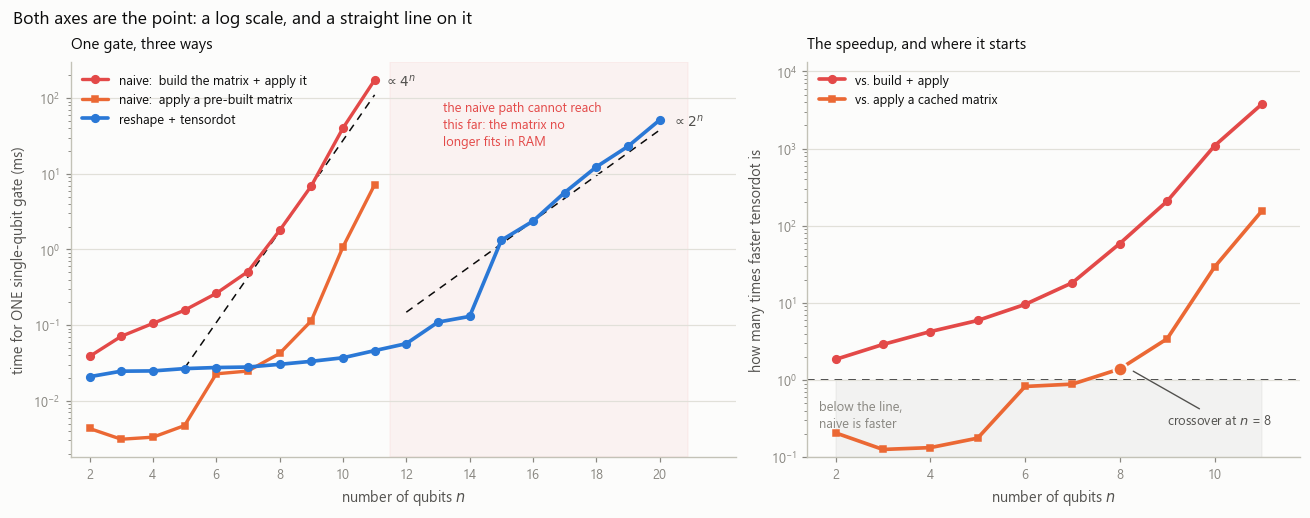

at n = 11, tensordot is 3773x faster than build+apply and 156x faster than apply-only.
the cached-matrix path stops winning at n = 8.


In [8]:
fig = plt.figure(figsize=(11.8, 4.6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1])

ax = fig.add_subplot(gs[0, 0])
ax.semilogy(ns_naive, t_naive * 1e3, color=style.RED, lw=2.2, marker="o", ms=5,
            label="naive:  build the matrix + apply it")
ax.semilogy(ns_naive, t_apply * 1e3, color=style.ORANGE, lw=2.2, marker="s",
            ms=4.5, label="naive:  apply a pre-built matrix")
ax.semilogy(ns_fast, t_fast * 1e3, color=style.BLUE, lw=2.4, marker="o", ms=5,
            label="reshape + tensordot")

# Slope guides, anchored on a real data point so they are honest.
anchor_n = 9
a_naive = t_naive[list(ns_naive).index(anchor_n)] * 1e3 / 4.0 ** anchor_n
gn = np.arange(5, 12)
ax.semilogy(gn, a_naive * 4.0 ** gn, color=style.INK, lw=1.0, ls=(0, (5, 4)),
            zorder=1)
ax.text(11.3, a_naive * 4.0 ** 11.3, r"$\propto 4^n$", fontsize=9,
        color=style.INK_2, va="center")

anchor_f = 16
a_fast = t_fast[list(ns_fast).index(anchor_f)] * 1e3 / 2.0 ** anchor_f
gf = np.arange(12, 21)
ax.semilogy(gf, a_fast * 2.0 ** gf, color=style.INK, lw=1.0, ls=(0, (5, 4)),
            zorder=1)
ax.text(20.4, a_fast * 2.0 ** 20.4, r"$\propto 2^n$", fontsize=9,
        color=style.INK_2, va="center")

ax.axvspan(N_NAIVE_MAX + 0.5, N_FAST_MAX + 0.9, color=style.RED, alpha=0.05,
           zorder=0)
# Axes fractions, not data coordinates: the y values here are wall-clock and
# move from machine to machine, so a data-space label would drift onto a curve.
ax.text(0.56, 0.90, "the naive path cannot reach\nthis far: the matrix no\n"
        "longer fits in RAM", transform=ax.transAxes,
        fontsize=8.5, color=style.RED, va="top", ha="left", linespacing=1.4)

ax.set_xlim(1.4, N_FAST_MAX + 2.4)
ax.set_xticks(range(2, N_FAST_MAX + 1, 2))
ax.set_xlabel("number of qubits $n$")
ax.set_ylabel("time for ONE single-qubit gate (ms)")
ax.set_title("One gate, three ways", loc="left", fontsize=10)
ax.legend(loc="upper left")

axr = fig.add_subplot(gs[0, 1])
common = [list(ns_fast).index(n) for n in ns_naive]
ratio_full = t_naive / t_fast[common]
ratio_cached = t_apply / t_fast[common]
axr.semilogy(ns_naive, ratio_full, color=style.RED, lw=2.4, marker="o", ms=5,
             label="vs. build + apply")
axr.semilogy(ns_naive, ratio_cached, color=style.ORANGE, lw=2.4, marker="s",
             ms=4.5, label="vs. apply a cached matrix")
axr.axhline(1.0, color=style.INK, lw=1.0, ls=(0, (5, 4)), zorder=1)
axr.fill_between(ns_naive, 1e-3, 1.0, color=style.MUTED, alpha=0.08, zorder=0)

# Where does the cached-matrix curve stop winning? That is the real crossover.
above = [int(n) for n, r in zip(ns_naive, ratio_cached) if r > 1.0]
CROSSOVER = above[0] if above else None
if CROSSOVER is not None:
    yc = ratio_cached[list(ns_naive).index(CROSSOVER)]
    axr.plot([CROSSOVER], [yc], marker="o", ms=9, color=style.ORANGE,
             markeredgecolor=style.SURFACE, markeredgewidth=1.4, zorder=5)
    grid.annotate(axr, f"crossover at $n$ = {CROSSOVER}",
                  xy=(CROSSOVER + 0.2, yc), xytext=(CROSSOVER + 1.0, 0.30),
                  color=style.INK_2)
axr.text(ns_naive[0] - 0.35, 0.55, "below the line,\nnaive is faster",
         fontsize=8.5, color=style.MUTED, va="top", linespacing=1.4)
axr.set_xlim(1.4, N_NAIVE_MAX + 0.8)
axr.set_ylim(0.1, max(ratio_full.max(), 10) * 3.5)
axr.set_xticks(range(2, N_NAIVE_MAX + 1, 2))
axr.set_xlabel("number of qubits $n$")
axr.set_ylabel("how many times faster tensordot is")
axr.set_title("The speedup, and where it starts", loc="left", fontsize=10)
axr.legend(loc="upper left")

fig.suptitle("Both axes are the point: a log scale, and a straight line on it",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"at n = {N_NAIVE_MAX}, tensordot is {ratio_full[-1]:.0f}x faster than "
      f"build+apply and {ratio_cached[-1]:.0f}x faster than apply-only.")
print(f"the cached-matrix path stops winning at n = {CROSSOVER}.")

Read the left panel as two straight lines with different slopes. On a
$\log$-$y$ axis against a linear $n$, a slope of one decade per 3.3 qubits is
$2^n$ and a slope of one decade per 1.66 qubits is $4^n$. The naive line is twice
as steep, and that factor of two in the exponent is the entire story.

The right panel is worth its own moment, because it is where an honest benchmark
disagrees with the sales pitch. **At small $n$ the cached-matrix path is
genuinely faster** — the orange curve starts *below* 1. Everything at that size is
Python-level overhead (a `tensordot` call, a `moveaxis`, a `reshape`, three NumPy
dispatches), and a $16\times16$ matrix-vector product is one BLAS call that beats
all of it. Asymptotics only take over once the arrays are big enough to matter.

The red curve, on the other hand, is above 1 from the very first point: once you
count the cost of *constructing* the matrix — which the naive simulator pays on
every single gate — there is no regime at all where it wins. And the crossover
for the cached version arrives well before the matrix stops fitting in memory, so
"just cache the matrices" was never a rescue either.

## Figure 4 — two walls: $2^n$ and $4^n$

A05 plotted the state wall: $16 \cdot 2^n$ bytes, and 29 qubits fills 8 GB. That
wall is a fact about quantum mechanics and there is no way around it with this
method.

The **operator wall** is different in kind, and this is the point of the notebook:
it is a wall you build yourself, out of a bad implementation choice.

$$\text{state: } 16\cdot 2^n \text{ bytes} \qquad\qquad
\text{dense operator: } 16 \cdot 4^n \text{ bytes}.$$

Set both against the same 8 GB budget and the arithmetic is brutal:

| | fits in 8 GB up to | |
|---|---|---|
| statevector, $16\cdot2^n$ | **29 qubits** | the real limit |
| dense gate matrix, $16\cdot4^n$ | **14 qubits** | the limit you invent |

Forming the matrix does not slow you down by a constant factor. It **halves the
number of qubits you can simulate at all**. Fifteen qubits, thrown away for the
convenience of writing `@`.

The same $4^n$ shows up again in A12 as the size of a density matrix — and there
it is not an implementation choice, it is what a mixed state genuinely costs.
Which is why simulating *noise* is so much harder than simulating a pure state,
and why the noisy notebooks in this repo stay small.

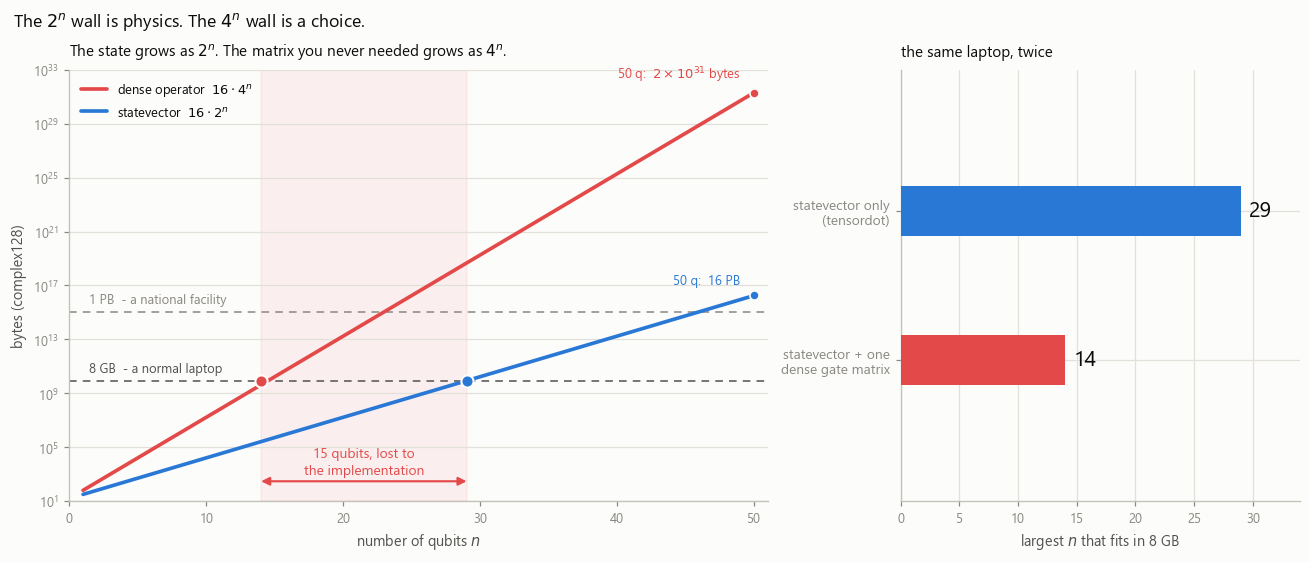

8 GB budget:  statevector up to n = 29,  dense operator up to n = 14
n = 10:  state    1.638e+04 B    operator    1.678e+07 B
n = 20:  state    1.678e+07 B    operator    1.759e+13 B
n = 30:  state    1.718e+10 B    operator    1.845e+19 B
n = 40:  state    1.759e+13 B    operator    1.934e+25 B
n = 50:  state    1.801e+16 B    operator    2.028e+31 B


In [9]:
GIB = 1024.0 ** 3
BUDGET = 8 * GIB

ns = np.arange(1, 51)
mem_state = 16.0 * 2.0 ** ns
mem_op = 16.0 * 4.0 ** ns

n_state = int(np.floor(np.log2(BUDGET / 16.0)))
n_op = int(np.floor(np.log2(BUDGET / 16.0) / 2))

fig = plt.figure(figsize=(11.8, 5.0))
gs = fig.add_gridspec(1, 2, width_ratios=[1.75, 1])

ax = fig.add_subplot(gs[0, 0])
ax.axvspan(n_op, n_state, color=style.RED, alpha=0.07, zorder=0)
ax.semilogy(ns, mem_op, color=style.RED, lw=2.4,
            label=r"dense operator  $16\cdot 4^n$")
ax.semilogy(ns, mem_state, color=style.BLUE, lw=2.4,
            label=r"statevector  $16\cdot 2^n$")

# 64 GB is deliberately left off: on a 30-decade axis it sits three pixels above
# the 8 GB line and the two labels collide for no informational gain.
for y, txt, col in [(BUDGET, "8 GB  - a normal laptop", style.INK_2),
                    (1024.0 ** 5, "1 PB  - a national facility", style.MUTED)]:
    ax.axhline(y, color=col, lw=1.0, ls=(0, (5, 4)), zorder=1)
    # Labelled on the LEFT: on the right they would sit on top of the
    # statevector curve, which crosses 1 PB at n = 47.
    ax.text(1.4, y * 2.6, txt, fontsize=8.5, color=col, ha="left", va="bottom")

for n_hit, col in [(n_op, style.RED), (n_state, style.BLUE)]:
    ax.plot([n_hit], [BUDGET], marker="o", ms=8, color=col,
            markeredgecolor=style.SURFACE, markeredgewidth=1.4, zorder=6)

ax.annotate("", xy=(n_op, 3e2), xytext=(n_state, 3e2),
            arrowprops=dict(arrowstyle="<|-|>", color=style.RED, lw=1.4,
                            shrinkA=0, shrinkB=0, mutation_scale=11))
ax.text((n_op + n_state) / 2, 6e2,
        f"{n_state - n_op} qubits, lost to\nthe implementation",
        ha="center", va="bottom", fontsize=9, color=style.RED, linespacing=1.4)

for yv, col, txt in [(16.0 * 2.0 ** 50, style.BLUE, "50 q:  16 PB"),
                     (16.0 * 4.0 ** 50, style.RED,
                      "50 q:  $2\\times10^{31}$ bytes")]:
    ax.plot([50], [yv], marker="o", ms=6.0, color=col,
            markeredgecolor=style.SURFACE, markeredgewidth=1.1, zorder=6)
    ax.text(49.0, yv * 4.0, txt, ha="right", va="bottom", fontsize=8.5, color=col)

ax.set_xlim(0, 51)
ax.set_ylim(1e1, 1e33)
ax.set_xticks(range(0, 51, 10))
ax.set_xlabel("number of qubits $n$")
ax.set_ylabel("bytes (complex128)")
ax.set_title("The state grows as $2^n$. The matrix you never needed grows as $4^n$.",
             loc="left", fontsize=10)
ax.legend(loc="upper left")

axb = fig.add_subplot(gs[0, 1])
bars = axb.barh([1, 0], [n_state, n_op], height=0.34,
                color=[style.BLUE, style.RED], zorder=3)
axb.set_yticks([1, 0])
axb.set_yticklabels(["statevector only\n(tensordot)",
                     "statevector + one\ndense gate matrix"], fontsize=9)
axb.set_ylim(-0.95, 1.95)
axb.set_xlabel("largest $n$ that fits in 8 GB")
axb.set_xlim(0, 34)
axb.grid(axis="x")
axb.set_axisbelow(True)
for b, v in zip(bars, [n_state, n_op]):
    axb.text(v + 0.7, b.get_y() + b.get_height() / 2, f"{v}", va="center",
             fontsize=14, color=style.INK, weight="medium")
axb.set_title("the same laptop, twice", loc="left", fontsize=10)

fig.suptitle("The $2^n$ wall is physics. The $4^n$ wall is a choice.",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"8 GB budget:  statevector up to n = {n_state},  "
      f"dense operator up to n = {n_op}")
for n in (10, 20, 30, 40, 50):
    print(f"n = {n:>2}:  state {16 * 2.0**n:>12.3e} B    "
          f"operator {16 * 4.0**n:>12.3e} B")

## 3. Wrapping it up as an actual simulator

Everything above is two functions. A simulator is those two functions plus
bookkeeping: hold the state, expose named gates, apply them in order.

`Sim` below is about thirty lines and it is a real, if minimal, statevector
simulator. Every gate goes through `apply_1q` / `apply_2q`, so nothing in it ever
allocates a $2^n \times 2^n$ array.

In [10]:
class Sim:
    """A minimal dense statevector simulator. Little-endian, qubit 0 rightmost."""

    def __init__(self, n):
        self.n = n
        self.psi = np.zeros(2 ** n, dtype=complex)
        self.psi[0] = 1.0                      # |00...0>
        self.gate_count = 0

    # --- the whole engine ------------------------------------------------
    def u1(self, U, k):
        self.psi = apply_1q(self.psi, U, k, self.n)
        self.gate_count += 1
        return self

    def u2(self, G, qa, qb):
        self.psi = apply_2q(self.psi, G, qa, qb, self.n)
        self.gate_count += 1
        return self

    # --- named gates, for readability only -------------------------------
    def h(self, k):
        return self.u1(H, k)

    def x(self, k):
        return self.u1(X, k)

    def z(self, k):
        return self.u1(Z, k)

    def rz(self, theta, k):
        return self.u1(rz(theta), k)

    def cx(self, control, target):
        return self.u2(CNOT4, qa=target, qb=control)   # qb is the pair high bit

    def cz(self, a, b):
        return self.u2(CZ4, qa=a, qb=b)

    # --- readout ---------------------------------------------------------
    def probabilities(self):
        return np.abs(self.psi) ** 2

    def sample(self, shots, rng):
        p = self.probabilities()
        return rng.choice(len(p), size=shots, p=p / p.sum())

    def nbytes(self):
        return self.psi.nbytes


# A 3-qubit GHZ, the hello-world of multi-qubit simulation.
ghz = Sim(3).h(0).cx(0, 1).cx(1, 2)
print("GHZ(3):")
print(grid.show_state(ghz.psi))
print(f"\n{ghz.gate_count} gates, {ghz.nbytes()} bytes of state, "
      f"norm = {np.linalg.norm(ghz.psi):.12f}")

GHZ(3):
  |000>  +0.7071+0.0000j
  |111>  +0.7071+0.0000j

3 gates, 128 bytes of state, norm = 1.000000000000


## Figure 5 — the simulator against pen and paper, and against the clock

**Left.** A four-qubit circuit whose output we can write down exactly:

1. $H$ on all four qubits — every amplitude becomes $\tfrac14$;
2. CZ on $(q_0, q_1)$ and CZ on $(q_2, q_3)$ — each flips the sign of the
   amplitudes where both of its qubits are 1;
3. $R_z(\pi/2)$ on $q_3$ — multiplies by $e^{-i\pi/4}$ where $b_3 = 0$ and
   $e^{+i\pi/4}$ where $b_3 = 1$.

So the closed form is

$$\psi_i = \tfrac14\,(-1)^{\,b_0 b_1 + b_2 b_3}\,e^{\,i\pi(2b_3-1)/4},$$

four distinct phases, all sixteen magnitudes equal. The bars confirm the
magnitudes, the hues and clock hands confirm the phases, and the printed number
underneath confirms both to $10^{-16}$.

**Right.** The clock. A GHZ chain on $n$ qubits is $n$ gates, each costing
$\mathcal{O}(2^n)$, so the whole circuit should cost $n\,2^n$ — very slightly
steeper than the single-gate line in Figure 3. That is exactly what comes out,
which is a small but real confirmation that nothing hidden is quadratic.

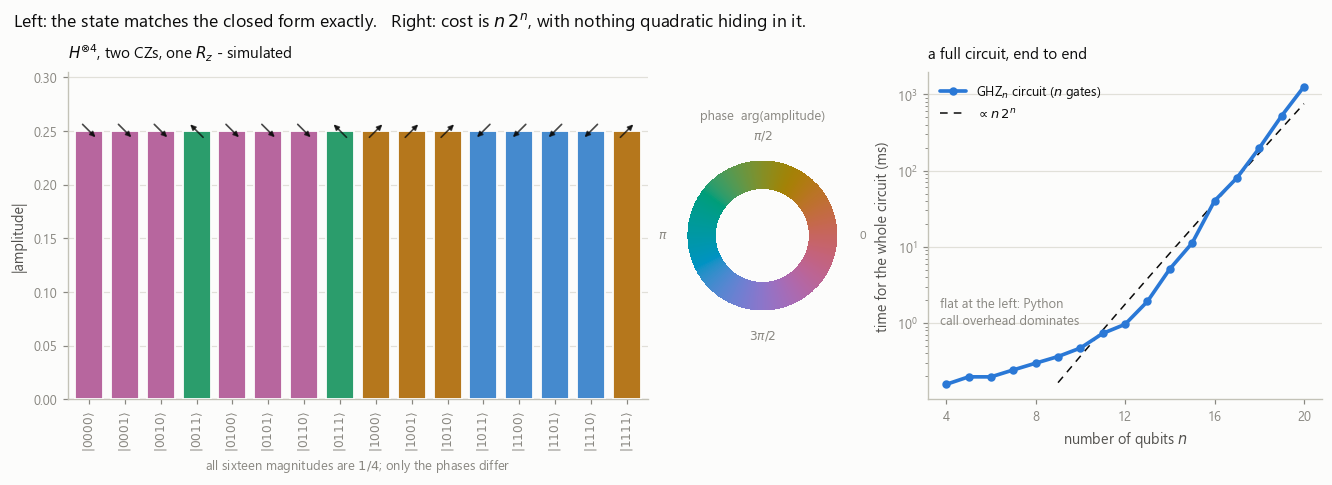

max |simulated - analytic| = 7.850e-17
distinct phases (units of pi): [np.float64(-0.75), np.float64(-0.25), np.float64(0.25), np.float64(0.75)]

GHZ(20): 20 qubits, 20 gates, 1259.6 ms, 16 MB of state
Naive would have needed a 1048576x1048576 matrix = 16 TB, per gate.


In [11]:
# ---- left: a circuit with a closed form
sim = Sim(4)
for q in range(4):
    sim.h(q)
sim.cz(0, 1)
sim.cz(2, 3)
sim.rz(np.pi / 2, 3)

idx = np.arange(16)
b0 = (idx >> 0) & 1
b1 = (idx >> 1) & 1
b2 = (idx >> 2) & 1
b3 = (idx >> 3) & 1
analytic = 0.25 * (-1.0) ** (b0 * b1 + b2 * b3) * np.exp(1j * np.pi * (2 * b3 - 1) / 4)

# ---- right: how long a whole GHZ circuit takes
def ghz_run(n):
    s = Sim(n)
    s.h(0)
    for q in range(n - 1):
        s.cx(q, q + 1)
    return s


ns_ghz = list(range(4, 21))
t_ghz = [bench(lambda n=n: ghz_run(n), min_time=0.02, max_reps=40)
         for n in ns_ghz]
t_ghz = np.array(t_ghz)

fig = plt.figure(figsize=(12.0, 4.3))
gs = fig.add_gridspec(1, 3, width_ratios=[1.55, 0.42, 1.05])

axa = fig.add_subplot(gs[0, 0])
grid.amp_bars(axa, sim.psi, ylim=0.305, label_rotation=90)
axa.set_title("$H^{\\otimes 4}$, two CZs, one $R_z$ - simulated", loc="left",
              fontsize=10)
axa.set_xlabel("all sixteen magnitudes are $1/4$; only the phases differ",
               fontsize=8.5, color=style.MUTED)

axw = fig.add_subplot(gs[0, 1], projection="polar")
style.phase_wheel(axw)

axt = fig.add_subplot(gs[0, 2])
axt.semilogy(ns_ghz, t_ghz * 1e3, color=style.BLUE, lw=2.4, marker="o", ms=4.5,
             label="GHZ$_n$ circuit ($n$ gates)")
anchor_g = 17
ref = t_ghz[ns_ghz.index(anchor_g)] * 1e3 / (anchor_g * 2.0 ** anchor_g)
gx = np.arange(9, 21, dtype=float)
axt.semilogy(gx, ref * gx * 2.0 ** gx, color=style.INK, lw=1.0, ls=(0, (5, 4)),
             zorder=1, label=r"$\propto n\,2^n$")
axt.text(0.03, 0.22, "flat at the left: Python\ncall overhead dominates",
         transform=axt.transAxes, fontsize=8.5, color=style.MUTED,
         va="bottom", ha="left", linespacing=1.4)
axt.set_xlabel("number of qubits $n$")
axt.set_ylabel("time for the whole circuit (ms)")
axt.set_xticks(range(4, 21, 4))
axt.set_title("a full circuit, end to end", loc="left", fontsize=10)
axt.legend(loc="upper left")

fig.suptitle("Left: the state matches the closed form exactly.   "
             "Right: cost is $n\\,2^n$, with nothing quadratic hiding in it.",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print("max |simulated - analytic| =", f"{np.max(np.abs(sim.psi - analytic)):.3e}")
print("distinct phases (units of pi):",
      sorted(set(np.round(np.angle(sim.psi) / np.pi, 6))))
print(f"\nGHZ(20): {ns_ghz[-1]} qubits, 20 gates, "
      f"{t_ghz[-1]*1e3:.1f} ms, {16 * 2**20 / 1024**2:.0f} MB of state")
print("Naive would have needed a", f"{2**20}x{2**20}",
      f"matrix = {16 * 4.0**20 / 1024**4:,.0f} TB, per gate.")

## Deep dive — why `tensordot` and not a hand-written loop

*Skip on a first read.*

The pairing picture in Figure 1 suggests an obvious implementation: loop over the
$2^{n-1}$ pairs and do the $2\times2$ arithmetic yourself. In C that is exactly
what a production simulator does, and it is the fastest thing possible — one pass
over memory, no temporaries.

In Python it is a disaster, because the loop runs in the interpreter. The whole
game in NumPy is to push the loop into compiled code, and `tensordot` does that by
reshaping the problem into a matrix multiply that BLAS already knows how to do:
contract axis $k$ of the state against $U$, which internally becomes a
$2 \times 2$ times $2 \times 2^{n-1}$ `gemm`.

There is one real cost we are paying. `moveaxis` followed by `reshape` cannot be
done as a view when the moved axis is not already at the front, so **every gate
allocates and copies the entire state**. A serious simulator applies gates *in
place*, indexing the pairs with a stride and never touching a second buffer. Ours
therefore uses about $2\times$ the memory it should and spends a good fraction of
its time in `memcpy`.

The cell below measures that cost by writing the strided in-place version — the
one Figure 1 draws — and racing it. It is not always faster in NumPy (the strided
version does two fancy-index gathers), but it shows the shape of what a real
implementation does, and it confirms the arithmetic once more.

In [12]:
def apply_1q_strided(psi, U, k, n):
    """The Figure 1 picture, written out: 2**(n-1) explicit 2x2 problems.

    Index i with bit k equal to 0 pairs with i + 2**k. Building that index list
    without a Python loop is the only trick here.
    """
    out = psi.copy()
    stride = 1 << k
    i = np.arange(2 ** n)
    lo = i[(i & stride) == 0]                  # every index whose qubit k is 0
    hi = lo + stride
    a, b = psi[lo], psi[hi]
    out[lo] = U[0, 0] * a + U[0, 1] * b
    out[hi] = U[1, 0] * a + U[1, 1] * b
    return out


for n in range(1, 8):
    st = random_state(rng, n)
    for k in range(n):
        U = haar_unitary(2, rng)
        assert np.allclose(apply_1q_strided(st, U, k, n), apply_1q(st, U, k, n),
                           atol=1e-13)
print("strided pairing == tensordot, n = 1..7, every qubit.")

n = 18
st = random_state(rng, n)
t_td = bench(lambda: apply_1q(st, H, n // 2, n))
t_st = bench(lambda: apply_1q_strided(st, H, n // 2, n))
print(f"\nn = {n}:  tensordot {t_td*1e3:.2f} ms   "
      f"explicit strided pairs {t_st*1e3:.2f} ms")
print("Both are O(2^n). The constant is where real simulators live.")

# What the copy costs: a gate's peak memory is 2x the state, not 1x.
print(f"\nstate: {st.nbytes / 1024**2:.1f} MB   "
      f"peak during one gate: about {2 * st.nbytes / 1024**2:.1f} MB")

strided pairing == tensordot, n = 1..7, every qubit.



n = 18:  tensordot 8.67 ms   explicit strided pairs 20.91 ms


Both are O(2^n). The constant is where real simulators live.

state: 4.0 MB   peak during one gate: about 8.0 MB


## Honest limits — what this toy cannot do

The simulator above is correct and it is asymptotically optimal for what it does.
It is also, in five separate ways, not a real simulator.

**It is dense, and it does not know it.** Every amplitude is stored, always, even
the $2^n - 1$ zeros in $|00\ldots0\rangle$. A circuit of only $X$ and CNOT gates
keeps the state a single basis vector forever — one non-zero amplitude — and we
faithfully multiply sixteen million zeros by it anyway. Sparse and
symbolic simulators exploit exactly this; we cannot, because we never look.

**It exploits no structure in the circuit.** Limited entanglement is the big one.
If a circuit's qubits stay only weakly correlated, a *matrix product state* can
represent it in memory linear in $n$ instead of exponential, and circuits on
hundreds of qubits become tractable. The $2^n$ wall is a wall around **general**
states, and most circuits people actually run are not general. C30 comes back to
this.

**Clifford circuits are secretly easy, and we pay full price for them anyway.**
A circuit built only from $H$, $S$ and CNOT can be simulated on *thousands* of
qubits in polynomial time — you track how the gates transform the Pauli operators
rather than tracking $2^n$ amplitudes, which is the Gottesman–Knill theorem. Our
`Sim` will happily grind through a 24-qubit Clifford circuit at 268 MB and full
exponential cost, learning nothing. Since almost every error-correction circuit in
C27 is Clifford, this matters enormously in practice. C30 tells that story
properly; the thing to take away here is that **"exponentially hard" is a property
of the method, not automatically of the circuit**.

**There is no noise, and adding it costs the $4^n$ back.** A statevector can only
represent a pure state. The moment a qubit decoheres you need a density matrix,
which is $2^n \times 2^n$ — the same $4^n$ we just spent the whole notebook
escaping, except now it is unavoidable rather than self-inflicted. A12 builds
that, and it is why the noisy notebooks in this repo use three or four qubits.

**Measurement here is a sampler, not a collapse.** `Sim.sample` draws from the
Born distribution but leaves the state alone. Real mid-circuit measurement
projects the state and renormalizes, which changes what every later gate does;
A04 built that properly, and dynamic circuits in B25 depend on it.

**Two smaller ones.** We copy the whole state on every gate (the deep dive
measured it), and we are single-threaded — a production simulator splits the
$2^{n-1}$ independent pairs across cores, which is close to perfectly parallel,
and then runs into memory bandwidth rather than arithmetic.

## Checkpoint

In [13]:
# 1. The fast path equals the naive path, exactly, for random gates on every
#    qubit and every ordered pair, n = 1..6.
for n in range(1, 7):
    st = random_state(rng, n)
    for k in range(n):
        U = haar_unitary(2, rng)
        assert np.allclose(apply_1q(st, U, k, n), op_on(U, k, n) @ st, atol=1e-13)
    for qa in range(n):
        for qb in range(n):
            if qa == qb:
                continue
            G = haar_unitary(4, rng)
            assert np.allclose(apply_2q(st, G, qa, qb, n),
                               op_on_pair(G, qa, qb, n) @ st, atol=1e-13)

# 2. ...and so does the explicit strided implementation.
for n in range(1, 8):
    st = random_state(rng, n)
    for k in range(n):
        U = haar_unitary(2, rng)
        assert np.allclose(apply_1q_strided(st, U, k, n), apply_1q(st, U, k, n),
                           atol=1e-13)

# 3. Little-endian, checked at the index level: X on qubit k of |0...0> must
#    land on index 2**k, and a gate on qubit k may only mix i with i ^ 2**k.
for n in range(1, 7):
    zero = np.zeros(2 ** n, dtype=complex)
    zero[0] = 1.0
    for k in range(n):
        assert int(np.argmax(np.abs(apply_1q(zero, X, k, n)))) == 2 ** k
        U = haar_unitary(2, rng)
        Mk = op_on(U, k, n)
        touched = {(i, j) for i, j in zip(*np.nonzero(np.abs(Mk) > 1e-12))}
        assert all(i == j or i == j ^ (1 << k) for i, j in touched)

# 4. Unitarity: the fast path preserves the norm exactly enough.
for n in (3, 7, 11):
    st = random_state(rng, n)
    for _ in range(10):
        st = apply_1q(st, haar_unitary(2, rng), int(rng.integers(n)), n)
    assert np.isclose(np.linalg.norm(st), 1.0, atol=1e-12)

# 5. Analytic ground truth for Figure 5's circuit.
assert np.allclose(sim.psi, analytic, atol=1e-13)
assert np.allclose(np.abs(sim.psi), 0.25)

# 6. H^(x)n on |0...0> is the uniform superposition, amplitude 2^(-n/2).
for n in (1, 4, 9):
    s = Sim(n)
    for q in range(n):
        s.h(q)
    assert np.allclose(s.psi, 2.0 ** (-n / 2))

# 7. GHZ_n has exactly two non-zero amplitudes, both 1/sqrt(2), at index 0 and
#    index 2**n - 1.
for n in (2, 5, 12):
    g = ghz_run(n)
    nz = np.flatnonzero(np.abs(g.psi) > 1e-12)
    assert list(nz) == [0, 2 ** n - 1]
    assert np.allclose(g.psi[nz], 1 / np.sqrt(2))
    assert g.gate_count == n

# 8. Gates are involutions / inverses where they should be, through Sim.
s = Sim(5)
for q in range(5):
    s.h(q)
s.cz(1, 3).cz(1, 3)                       # CZ squared = identity
for q in range(5):
    s.h(q)
z0 = np.zeros(32, dtype=complex)
z0[0] = 1.0
assert np.allclose(s.psi, z0, atol=1e-13)

# 9. Two-qubit gates on non-adjacent qubits behave: CNOT(control q4, target q0)
#    on |10000> gives |10001>.
s = Sim(5).x(4).cx(4, 0)
assert int(np.argmax(np.abs(s.psi))) == 0b10001

# 10. The memory claims in Figure 4 are arithmetic, so assert the arithmetic.
assert 16 * 2 ** n_state <= BUDGET < 16 * 2 ** (n_state + 1)
assert 16 * 4 ** n_op <= BUDGET < 16 * 4 ** (n_op + 1)
assert n_state == 29 and n_op == 14

# 11. Timings vary run to run, so nothing above asserts a wall-clock number --
#     only that the fast path never allocated anything of size 4**n.
assert Sim(12).psi.nbytes == 16 * 2 ** 12

print("A07 checkpoint passed.")

A07 checkpoint passed.


---

## What to take away

- A statevector is $2^n$ numbers. A gate applied to it should cost $\mathcal{O}(2^n)$,
  and it does — as $2^{n-1}$ independent $2\times2$ multiplies picked out by a
  stride of $2^k$.
- `reshape((2,)*n)` is free. It costs nothing and it turns "apply a gate to qubit
  $k$" into "contract axis $n-1-k$", which is a one-liner NumPy already optimises.
- Building the operator matrix is not a slow-but-equivalent choice. It squares the
  memory and halves the number of qubits you can reach.
- The wall at ~29 qubits is real for *general* states. It is not a wall around
  every circuit, and the rest of the repo keeps returning to that distinction.

**Next:** [A08 — Interference and Phase Kickback](A08_Interference_Phase_Kickback.ipynb). We now
have a simulator fast enough to run circuits worth watching. So let's point it at
the thing that makes quantum computing work at all: amplitudes cancelling.